## K means clustering

MNIST bestaat uit plaatjes van cijfers (0 t/m 9).
Elk plaatje is een lijst van 784 pixelwaardes.
Om data te comprimeren willen we K means clustering toepassen om prototypes te maken.

### Opdracht 1

Wat stelt één prototype voor?

Een prototype is het gemiddelde plaatje van een groep vergelijkbare cijfers. Als je bijvoorbeeld alle "3"-en in 5 groepen splitst, krijg je 5 prototypes die elk een andere schrijfstijl van de "3" laten zien.

Waarom is dit geheugenbesparend?

In plaats van alle 60.000 trainingsafbeeldingen op te slaan, slaan we alleen de prototypes op. Bij k=5 per cijfer heb je maar 50 prototypes. Dat is veel minder data.

Schrijf een functie **load_mnist** die de MNIST-data laadt en de pixelwaarden schaalt naar 0–1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

def load_mnist():
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    # Flatten: van 28x28 naar 784 pixels per plaatje
    X_train = X_train.reshape(-1, 784).astype(np.float32)
    X_test = X_test.reshape(-1, 784).astype(np.float32)

    # Schaal naar 0-1
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_mnist()
print(f"Train: {X_train.shape} (labels: {y_train.shape})")
print(f"Test:  {X_test.shape} (labels: {y_test.shape})")
print(f"Pixelwaarden: {X_train.min():.1f} - {X_train.max():.1f}")

Train: (60000, 784) (labels: (60000,))
Test:  (10000, 784) (labels: (10000,))
Pixelwaarden: 0.0 - 1.0


### Stap 2: Prototypes maken

We maken per cijfer een aantal prototypes (gemiddelde plaatjes).

Schrijf een functie **make_prototype** die:
- Voor elk cijfer (0–9) de bijbehorende trainingsbeelden selecteert
- Met K-means k clusters maakt
- Alle cluster-centers opslaat als prototypes
- Per prototype het juiste cijfer onthoudt
- Alle prototypes en bijbehorende labels returnt

We gebruiken twee **numpy arrays**: één voor de prototypes en één voor de labels. Dit is handig omdat numpy arrays snel zijn en je makkelijk kunt rekenen met de pixelwaarden.

In [ ]:
from sklearn.cluster import KMeans

def make_prototype(X_train, y_train, k=5):
    prototypes = []
    labels = []

    for cijfer in range(10):
        # Pak alle afbeeldingen van dit cijfer
        mask = (y_train == cijfer)
        X_cijfer = X_train[mask]

        # Maak k clusters met KMeans
        km = KMeans(n_clusters=k, random_state=50, n_init=10)
        km.fit(X_cijfer)

        # Sla de cluster centers op als prototypes
        for center in km.cluster_centers_:
            prototypes.append(center)
            labels.append(cijfer)

    prototypes = np.array(prototypes)
    labels = np.array(labels)

    return prototypes, labels

Maak nu een stukje code waarmee je de bovenstaande functies aanroept en een (of meer) van de prototypes laat zien.

Aantal prototypes: 30
Shape per prototype: (784,)


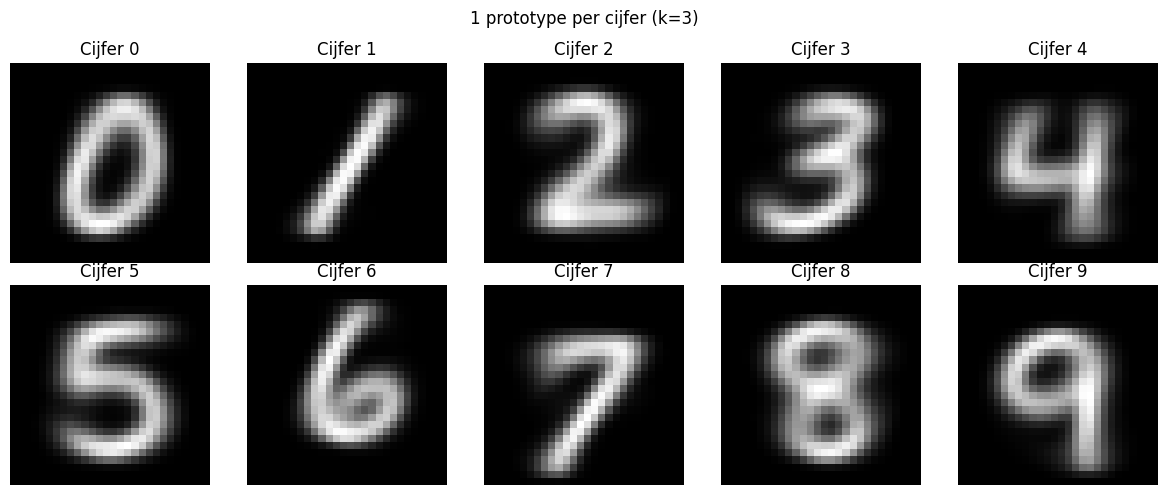

In [3]:
# Maak prototypes met k=3 per cijfer
prototypes, proto_labels = make_prototype(X_train, y_train, k=3)
print(f"Aantal prototypes: {len(prototypes)}")
print(f"Shape per prototype: {prototypes[0].shape}")

# Laat van elk cijfer 1 prototype zien
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cijfer in range(10):
    ax = axes[cijfer // 5][cijfer % 5]
    idx = proto_labels == cijfer
    proto = prototypes[idx][0]
    ax.imshow(proto.reshape(28, 28), cmap='gray')
    ax.set_title(f"Cijfer {cijfer}")
    ax.axis('off')
plt.suptitle("1 prototype per cijfer (k=3)")
plt.tight_layout()
plt.show()

### Stap 3 – Cijfers voorspellen

We willen het cijfer voorspellen door te kijken naar de afstand tot een prototype.
Een onbekend plaatje wordt vergeleken met alle prototypes.

Schrijf een functie **get_distance(image1, image2)** die de som van alle pixelverschillen teruggeeft.

In [4]:
def get_distance(image1, image2):
    # Som van de absolute verschillen per pixel
    afstand = np.sum(np.abs(image1 - image2))
    return afstand

# Test
print("Afstand naar zichzelf:", get_distance(X_test[0], X_test[0]))
print("Afstand naar ander plaatje:", round(get_distance(X_test[0], X_test[1]), 2))

Afstand naar zichzelf: 0.0
Afstand naar ander plaatje: 153.69


Schrijf een functie **predict** die:
- Voor elk testplaatje de afstand tot alle prototypes berekent
- Het prototype kiest dat het meest lijkt
- Het bijbehorende cijfer teruggeeft

**Wat betekent "afstand" hier?**
De afstand is het verschil tussen twee plaatjes, pixel voor pixel. Hoe kleiner de afstand, hoe meer ze op elkaar lijken.

**Waarom de kleinste afstand?**
Het prototype met de kleinste afstand lijkt het meest op het testplaatje. Dus dat cijfer is waarschijnlijk het juiste antwoord.

In [ ]:
def predict(image, prototypes, proto_labels):
    # inf omdat de afstand oneidig groot "kan" zijn
    kleinste_afstand = float('inf')
    beste_label = -1

    for i in range(len(prototypes)):
        afstand = get_distance(image, prototypes[i])

        if afstand < kleinste_afstand:
            kleinste_afstand = afstand
            beste_label = proto_labels[i]

    return beste_label

Probeer nu een random afbeelding te voorspellen aan de hand van je **predict** functie.

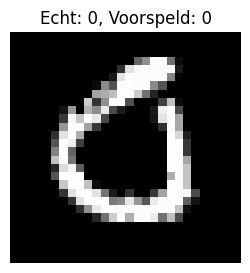

Correct!


In [6]:
# Kies een random testafbeelding
idx = np.random.randint(0, len(X_test))
test_img = X_test[idx]
echt_label = y_test[idx]

voorspelling = predict(test_img, prototypes, proto_labels)

plt.figure(figsize=(3, 3))
plt.imshow(test_img.reshape(28, 28), cmap='gray')
plt.title(f"Echt: {echt_label}, Voorspeld: {voorspelling}")
plt.axis('off')
plt.show()

if voorspelling == echt_label:
    print("Correct!")
else:
    print("Fout!")

### Stap 4 – Experimenteren

Schrijf code die:
- Prototypes maakt met verschillende k-waarden
- Voorspellingen doet
- De accuracy berekent
- Het geheugengebruik van de prototypes print

Test met k = 1, 3, 5, 10.

In [7]:
# Test met verschillende waarden van k
resultaten = []

for k in [1, 3, 5, 10]:
    print(f"\n--- k = {k} ---")

    protos, plabels = make_prototype(X_train, y_train, k=k)

    # Voorspel de eerste 500 testafbeeldingen
    aantal_test = 500
    voorspellingen = []
    for i in range(aantal_test):
        v = predict(X_test[i], protos, plabels)
        voorspellingen.append(v)

    voorspellingen = np.array(voorspellingen)

    accuracy = np.mean(voorspellingen == y_test[:aantal_test])
    geheugen = protos.nbytes

    print(f"  Prototypes: {len(protos)}")
    print(f"  Accuracy: {accuracy:.2%}")
    print(f"  Geheugen: {geheugen} bytes ({geheugen/1024:.1f} KB)")

    resultaten.append((k, accuracy, geheugen))

# Samenvatting
print("\n" + "=" * 50)
print(f"  {'k':>3}  {'Accuracy':>10}  {'Geheugen':>12}")
print("=" * 50)
for k, acc, mem in resultaten:
    print(f"  {k:>3}  {acc:>9.2%}  {mem:>8} bytes")
print("=" * 50)
print("\nMeer prototypes = betere accuracy maar meer geheugen.")
print("k=5 is een goede balans.")


--- k = 1 ---
  Prototypes: 10
  Accuracy: 62.60%
  Geheugen: 31360 bytes (30.6 KB)

--- k = 3 ---
  Prototypes: 30
  Accuracy: 75.60%
  Geheugen: 94080 bytes (91.9 KB)

--- k = 5 ---
  Prototypes: 50
  Accuracy: 76.60%
  Geheugen: 156800 bytes (153.1 KB)

--- k = 10 ---
  Prototypes: 100
  Accuracy: 81.40%
  Geheugen: 313600 bytes (306.2 KB)

    k    Accuracy      Geheugen
    1     62.60%     31360 bytes
    3     75.60%     94080 bytes
    5     76.60%    156800 bytes
   10     81.40%    313600 bytes

Meer prototypes = betere accuracy maar meer geheugen.
k=5 is een goede balans.
